# Justificación de mis controles
Tengo que encontrar la manera de justificar la elección de mis controles.

In [88]:
import os
import sys
sys.path.insert(1, '../')

import math
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from grid_builder import GridBuilder
from shapely.geometry import LineString, MultiLineString, Polygon


warnings.filterwarnings("ignore")
PATH_DATA = '../../data/'
CRS = 4326

In [89]:
vialidades = (
    gpd
    .read_file(os.path.join(PATH_DATA, 'vialidades.json'))
    .assign(
        tipo_vialidad=lambda x: x.TIPO_VIA.map({
            "Vía primaria":"primaria", 
            'Vía de acceso controlado':'acceso_controlado'
        }),
        carriles=lambda x: pd.to_numeric(x.CARRILES, errors='raise'),
        sentidos=lambda x: x.CIRCULA.map({
            "Un sentido":1, 
            "Dos sentidos":2, 
            "Un sentido con carril de contraflujo":2
        })
    )
    .rename({
        'NIVEL':'nivel', 
        'NOMENCLAT':'calle', 
        'NOMBRE':'vialidad', 
        'ID_VIA':'id_via'
    }, axis=1)
    [[
        'id_via', 'vialidad', 'calle', 'tipo_vialidad', 
        'carriles', 'sentidos', 'nivel', 'geometry'
    ]]
    .to_crs(CRS)
)

speed_cameras = gpd.read_file(
    os.path.join(
        PATH_DATA,
        'fotocivicas-ubicacion-puntos',
        'fotocivicas-ubicacion-puntos.shp'
    )
).to_crs(CRS)

In [90]:
# A ver, vamos a graficar solo el grid de una cámara
gb = GridBuilder()

In [91]:
circle = gb.create_circle_grid(gdf=speed_cameras.query('ubi == 52'), r=30, n=1).query('fila == 0 and columna == 0')
circle = circle.geometry.values[0]

In [94]:
vialidades[vialidades.within(circle)]

,id_via,vialidad,calle,tipo_vialidad,carriles,sentidos,nivel,geometry


In [87]:
circle.

AttributeError: 'Polygon' object has no attribute 'get_crs'

In [85]:
vialidades[vialidades.within(circle)]

,id_via,vialidad,calle,tipo_vialidad,carriles,sentidos,nivel,geometry


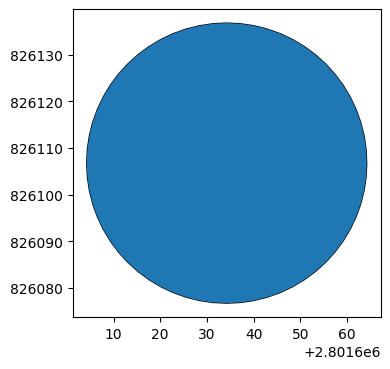

In [53]:
fig, ax = plt.subplots(figsize=(4,4))

circle.set_geometry('circle_geometry').plot(ax=ax, facecolor="none")
vialidades_in_circle.plot(ax=ax)

plt.show()